In [21]:

from operator import add
from typing import Annotated

from langchain.chat_models import init_chat_model
from langgraph.graph import END, START, StateGraph
from langgraph.types import Send
from typing_extensions import TypedDict

llm = init_chat_model("openai:gpt-4o-mini")

In [22]:
from pydantic import BaseModel, Field


class Criteria(BaseModel):
    step: int = Field(..., description="풀이 단계 번호, 1부터")
    description: str = Field(..., description="이 단계에서 하는 계산/적용 (한 줄)")
    score: int = Field(..., description="이 단계 배점")
    
class ProblemType(BaseModel):
    problem: str = Field(..., description="주관식 문제 본문")
    answer: str = Field(..., description="최종 정답. 12, (가), 3√2 처럼 값 하나")
    criteria: list[Criteria] = Field(..., description="채점용 풀이 단계와 배점")

class SolverType(BaseModel):
    solver_answer: str = Field(..., description="평가자가 문제를 직접 다시 풀어서 얻은 정답")
    solver_steps: str = Field(..., description="평가자가 실제로 푼 과정 요약")
    problem_score: int = Field(..., description="문제 자체 품질 1~10. 조건 명확성, 주관식 적합성, 개념 적합성")
    answer_correct: bool = Field(..., description="출제자의 정답이 평가자 정답과 일치하는가")
    criteria_correct: bool = Field(..., description="출제자의 풀이 단계/접근이 수학적으로 옳은가")
    retry_reason: str = Field("", description="재생성할 때만 채움. 통과면 빈 문자열")
    
class State(TypedDict):
    user_query: str
    problems: ProblemType
    loop_count: int
    problem_score: int
    answer_correct: bool
    criteria_correct: bool
    solver_answer: str
    solver_steps: str
    retry_reason: Annotated[list[str], add]
    final_problem: str

In [23]:
from typing import Literal


MAX_LOOPS = 3

def problem_maker(state: State):
    
    structured_llm = llm.with_structured_output(ProblemType)
    retry_reasons = state.get("retry_reason") or []

    problem = structured_llm.invoke(
        f"""
        당신은 수학 주관식 문항 출제자다.
        학생의 계산 결과만 보고 정오를 가릴 수 있는 문항을 1개 만든다.
        개념: {state.get("user_query")}
        [문항 형식 — 반드시 주관식]
        - 답이 하나의 값으로 떨어진다. 예: 12, -3, (가), 3√2, (2, -1)
        - 서술형 금지. "설명하시오", "이유를 쓰시오" 금지.
        - 조건 → 구하는 것 순서. 짧게.
        [반드시 함께 생성]
        1. problem: 문제 본문만. 정답/힌트 넣지 말 것.
        2. answer: 최종 정답 값 하나.
        3. criteria: 풀이 단계. step, description, score. 배점 합계 10점.
        [이전 평가 피드백]
        목록이 비어 있으면 첫 출제다.
        값이 있으면 평가 노드가 반려한 이유다. 같은 문항을 미세수정하지 말고, 지적을 반영한 새 문항을 만들어라.
        반려 이유: {retry_reasons}
        
        """
    )
    
    return {
        "problems": problem,
        "loop_count": state.get("loop_count", 0) + 1
    }

def problem_solver(state: State):

    structured_llm = llm.with_structured_output(SolverType)
    problem = state.get("problems")

    evaluation = structured_llm.invoke(
        f"""
        당신은 수학 주관식 문제 검증 전문가입니다.
        출제자의 정답을 믿으면 안 된다. 정답과 풀이 과정을 가리고 
        직접 풀어본 다음, 출제 결과와 대조해야 합니다.

        개념: {state.get("user_query")}

        [출제 결과]
        문제: {problem.problem}
        출제자 정답: {problem.answer}
        출제자 풀이 단계:
        {problem.criteria}

        [할 일]
        1. 문제를 처음부터 직접 풀어 solver_answer, solver_steps를 적어라.
        2. problem_score (1~10): 문제 자체 품질만 본다.
        - 주관식으로 답이 떨어지는가
        - 조건이 충분한가 / 과하거나 모호하지 않은가
        - 해당 개념을 실제로 묻나
        - 계산 가능한 유일한 정답이 있는가
        3. answer_correct: 출제자 정답 == 네가 푼 정답
        4. criteria_correct: 출제자 풀이 단계가 수학적으로 옳고, 그 경로로 정답이 나오는가
        5. retry_reason:
        - 통과면 빈 문자열
        - 실패면 출제자가 고칠 수 있게 구체적으로 써라.
            예) "문제 조건이 부족해서 답이 유일하지 않다"
            예) "문제 자체는 괜찮으나 출제자 정답 5는 틀렸다. 올바른 정답은 13이다. 2단계 대입이 잘못되었다"
        [실패 기준 — 하나라도 해당하면 재생성]
        - 문제 품질이 5점 이하
        - 문제 품질은 6점 이상이어도 정답이 틀림
        - 문제 품질은 6점 이상이어도 풀이 단계/접근이 틀림
    
        """
    )
    result= {
        "problem_score": evaluation.problem_score,
        "answer_correct": evaluation.answer_correct,
        "criteria_correct": evaluation.criteria_correct,
        "solver_answer": evaluation.solver_answer,
        "solver_steps": evaluation.solver_steps, 
    }

    if _needs_retry(evaluation) and evaluation.retry_reason:
        result["retry_reason"] = [evaluation.retry_reason]
    return result


def _needs_retry(evaluation: SolverType) -> bool:
    quality_bad = evaluation.problem_score <= 5
    solution_bad = (not evaluation.answer_correct) or (not evaluation.criteria_correct)
    return quality_bad or solution_bad

def route_after_solver(state: State) -> Literal["problem_maker", "problem_output"]:
    # 몇 번 돌려도 안 되면 현재 결과라도 출력
    if state.get("loop_count", 0) >= MAX_LOOPS:
        return "problem_output"
    quality_ok = state.get("problem_score", 0) >= 6
    answer_ok = state.get("answer_correct") is True
    criteria_ok = state.get("criteria_correct") is True
    if quality_ok and answer_ok and criteria_ok:
        return "problem_output"
    return "problem_maker"


def problem_output(state: State):
    problem = state["problems"]
    steps = "\n".join(
        f"{c.step}. {c.description} ({c.score}점)" for c in problem.criteria
    )
    final_problem = f"""
    [문제]
    {problem.problem}
    [정답]
    {problem.answer}
    [채점 기준]
    {steps}
    [검증]
    품질 {state.get("problem_score")}/10
    평가자 정답: {state.get("solver_answer")}
    정답 일치: {state.get("answer_correct")}
    풀이 타당: {state.get("criteria_correct")}
    재시도 횟수: {state.get("loop_count")}
    """.strip()
    return {"final_problem": final_problem} 


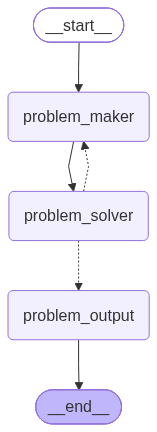

In [24]:
graph_builder = StateGraph(State)
graph_builder.add_node("problem_maker", problem_maker)
graph_builder.add_node("problem_solver", problem_solver)
graph_builder.add_node("problem_output", problem_output)
graph_builder.add_edge(START, "problem_maker")
graph_builder.add_edge("problem_maker", "problem_solver")
graph_builder.add_conditional_edges(
    "problem_solver",
    route_after_solver,
    {
        "problem_maker": "problem_maker",
        "problem_output": "problem_output",
    },
)
graph_builder.add_edge("problem_output", END)
graph = graph_builder.compile()

graph

In [25]:
graph.invoke({"user_query": "부정적분"})

/Users/kimminki/Desktop/study/nomadcoder-ai-master-class/workflow-architectures/.venv/lib/python3.13/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=ProblemType(problem='다... 구하기', score=3)]), input_type=ProblemType])
  return self.__pydantic_serializer__.to_python(
/Users/kimminki/Desktop/study/nomadcoder-ai-master-class/workflow-architectures/.venv/lib/python3.13/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=SolverType(solver_answer=...t=True, retry_reason=''), input_type=SolverType])
  return self.__pydantic_serializer__.to_python(


{'user_query': '부정적분',
 'problems': ProblemType(problem='다음 함수를 부정적분하시오: f(x) = 3x^2 - 5x + 2', answer='x^3 - (5/2)x^2 + 2x + C', criteria=[Criteria(step=1, description='3x^2의 부정적분 구하기', score=4), Criteria(step=2, description='-5x의 부정적분 구하기', score=3), Criteria(step=3, description='2의 부정적분 구하기', score=3)]),
 'loop_count': 1,
 'problem_score': 7,
 'answer_correct': True,
 'criteria_correct': True,
 'solver_answer': '∫f(x)dx = ∫(3x^2 - 5x + 2)dx\n= ∫3x^2dx - ∫5xdx + ∫2dx\n= (3/3)x^3 - (5/2)x^2 + 2x + C\n= x^3 - (5/2)x^2 + 2x + C',
 'solver_steps': '1단계: 3x^2의 부정적분 구하기: ∫3x^2dx = x^3 + C\n2단계: -5x의 부정적분 구하기: ∫(-5x)dx = -(5/2)x^2 + C\n3단계: 2의 부정적분 구하기: ∫2dx = 2x + C\n=> 최종합: 부정적분은 x^3 - (5/2)x^2 + 2x + C',
 'retry_reason': [],
 'final_problem': '[문제]\n    다음 함수를 부정적분하시오: f(x) = 3x^2 - 5x + 2\n    [정답]\n    x^3 - (5/2)x^2 + 2x + C\n    [채점 기준]\n    1. 3x^2의 부정적분 구하기 (4점)\n2. -5x의 부정적분 구하기 (3점)\n3. 2의 부정적분 구하기 (3점)\n    [검증]\n    품질 7/10\n    평가자 정답: ∫f(x)dx = ∫(3x^2 - 5x + 2)dx\n= ∫3x^2dx -